# Prepara y estructura datos con Python IV 🐍🖥️✍️

## Objetivos academicos

- Aplicar limpieza, estandarización y validación de tipos de datos.
- Filtrar y enfocar el análisis en ciudades latinoamericanas.
- Calcular indicadores agregados (por ciudad–año).
- Realizar análisis exploratorios y visuales.


## Proyecto Final: Movilidad urbana y productividad económica en ciudades de LATAM  📊🚲🚗🏙️

---

### **Introducción**

Eres analista de datos en el Latin American Development Bank.Tu equipo debe entregar un reporte para entender cómo la movilidad urbana (niveles de congestión, tiempos de viaje, retrasos) se relaciona con la productividad económica (PIB per cápita, desempleo) en las principales ciudades latinoamericanas.El objetivo del banco es identificar en qué ciudades invertir en infraestructura de transporte para aumentar la productividad y el bienestar de la población.
Para ello, usarás dos fuentes reales de datos:

- Movilidad urbana: TomTom Traffic Index (datos de tráfico en tiempo real).
- Economía urbana: OECD Cities (PIB per cápita, desempleo y población).

**Tu misión será limpiar, unir y analizar ambas bases para obtener información útil para la toma de decisiones.**

### **💡 Preguntas del negocio:**

- ¿Qué ciudades de América Latina presentan alta congestión y baja productividad económica?
- ¿Cuáles muestran los mejores indicadores combinados (movilidad eficiente y economía fuerte)?
- ¿Qué variables parecen tener una relación más fuerte con el desarrollo urbano?


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
sns.set_style('whitegrid')
sns.set_palette('pastel')

### Carga de datos y exploracion

**Datos**

- `tomtom_traffic.csv` : Datos sobre congestión vehicular y condiciones de tráfico en ciudades del mundo.
- `oecd_city_economy.csv` : Indicadores económicos y ambientales por ciudad, recopilados por la OECD (Organización para la Cooperación y el Desarrollo Económico).

> Ambas tablas se complementan para entender cómo la eficiencia del tráfico urbano se relaciona con el desempeño económico en ciudades latinoamericanas.

In [29]:
tomtom_traffic=pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/tomtom_traffic.csv')
oecd_city_economy=pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/oecd_city_economy.csv')

**Tareas a realizar**

- Muestra algunas filas
- Determina la estructura de cada *dataset*: filas,columnas, tipo de datos
- Determina si existe problemas con el tipo de datos, la cantidad de datos nulos

 

#### Pista 💡

In [30]:
tomtom_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [31]:
oecd_city_economy.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


### Limpieza y preparación de los datos 🧹💻📊🧾

**Tareas a realizar**

- Renombra las columnas que consideres necesarias (Convierte a `snake_case` las que consideres relevantes))
- Procesa columnas de tipo numerico y fecha
- Crea las siguientes columnas:
    - `tomtom_traffic`
        - `year` donde contengas el año a partir de `update_time`

 

#### Pista 💡

In [32]:
oecd_city_economy.rename(columns={'City GDP/capita':'city_gdp_capita'},inplace=True)

In [33]:
oecd_city_economy['city_gdp_capita']=oecd_city_economy['city_gdp_capita'].str.replace('.','').str.replace(',','.')
oecd_city_economy['city_gdp_capita']=pd.to_numeric(oecd_city_economy['city_gdp_capita'])
oecd_city_economy

,Year,City,Country,city_gdp_capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,15999.0,8.3%,"13,50","4,70"
4,2023,salvador,Brazil,8761.0,13.1%,"16,00","3,90"
5,2023,fortaleza,Brazil,838.0,12.5%,"15,40","4,20"
6,2023,belo-horizonte,Brazil,10951.0,10.1%,"17,50","6,00"
7,2023,curitiba,Brazil,12189.0,8.8%,"14,20","3,60"
8,2023,recife,Brazil,9047.0,11.8%,"16,50","4,10"
9,2023,porto-alegre,Brazil,11618.0,9.2%,"14,90","4,30"


In [34]:
tomtom_traffic['update_time']= pd.to_datetime(tomtom_traffic['UpdateTimeUTC'])
tomtom_traffic['year']= tomtom_traffic['update_time'].dt.year
tomtom_traffic

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay,update_time,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025-01-13 04:01:30.001,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025-01-13 03:46:00.000,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025-01-13 02:46:30.000,2025
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238,2025-01-13 01:46:30.001,2025
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016,2025-01-13 00:01:30.000,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004459,ZAF,pretoria,2024-10-01 12:31:30.000,195.1,27.0,27.2,66.0,14.0,2024-09-24 12:01:30.001,14.930880,14.129215,0.801665,2024-10-01 12:31:30.000,2024
1004460,ZAF,pretoria,2024-10-01 11:31:30.000,78.3,22.0,9.2,27.0,15.0,2024-09-24 11:01:30.000,13.973285,13.630819,0.342466,2024-10-01 11:31:30.000,2024
1004461,ZAF,pretoria,2024-10-01 10:01:30.000,85.0,21.0,9.7,29.0,16.0,2024-09-24 10:16:30.001,13.690491,13.287302,0.403189,2024-10-01 10:01:30.000,2024
1004462,ZAF,pretoria,2024-10-01 09:01:30.000,68.1,20.0,6.7,23.0,15.0,2024-09-24 09:46:30.000,13.387203,12.983558,0.403646,2024-10-01 09:01:30.000,2024


### 🧩 Analizar y resumir datos de movilidad


**Tareas a realizar**

- Calcula los promedios por tráfico por ciudad
- Calcula el % promedio de deseempleo por pais 
- Calcula el total de retrasos en minutos debidos al embotellamientos por ciudad (Muestra las 10 principales)

#### Pista 💡

In [39]:
tomtom_traffic.groupby('City')['JamsDelay'].sum().reset_index().sort_values(by=['JamsDelay'],ascending=[False])

,City,JamsDelay
218,mexico-city,6848319.6
349,tokyo,5269827.8
243,new-york,5241285.8
197,london,5111001.3
208,manila,4397125.2
...,...,...
110,dunedin,11188.3
360,uppsala,10781.0
122,fujairah,10521.9
12,almere,8830.9


### 🕵️ 🧩  Visualización y análisis de relaciones

**Tareas a realizar**

- Muestra como se distribuyen por ciudad el ingreso per cápita, la población, el tiempo de embotellamiento, cantidad de embotellamiento 
- Muestra un grafico de barras con la población por pais
- Muestra si existe alguna relación entre la población y los embotellamientos 


#### Pista 💡

<Axes: ylabel='Frequency'>

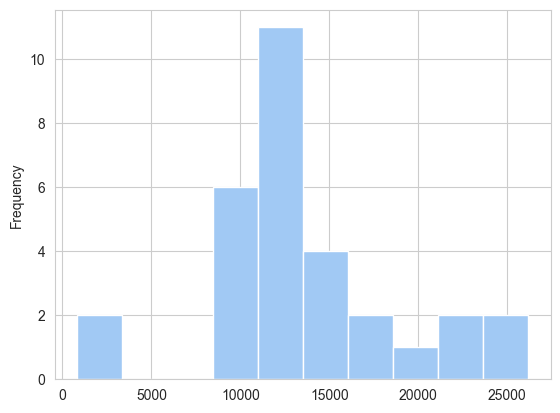

In [42]:
oecd_city_economy['city_gdp_capita'].plot(kind='hist')

<Axes: xlabel='city_gdp_capita'>

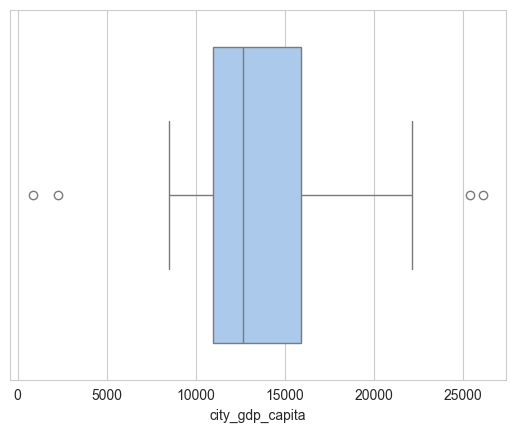

In [43]:
sns.boxplot(data=oecd_city_economy,x='city_gdp_capita')

<Axes: xlabel='city_gdp_capita', ylabel='Country'>

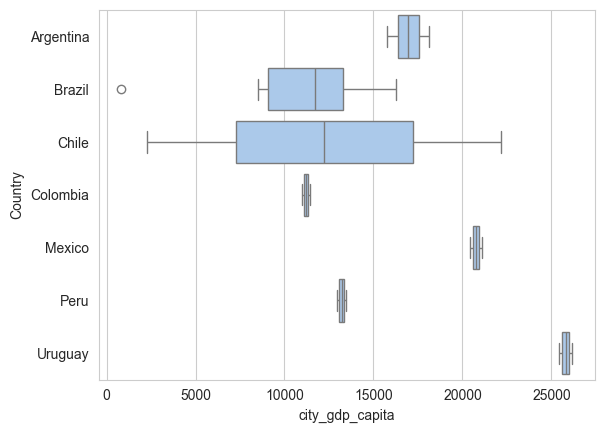

In [45]:
sns.boxplot(data=oecd_city_economy,x='city_gdp_capita',y='Country')

<Axes: xlabel='Country'>

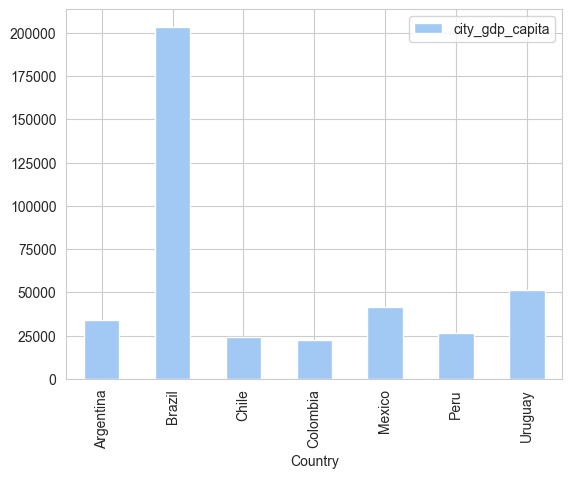

In [50]:
oecd_city_economy.groupby('Country')['city_gdp_capita'].sum().reset_index().plot(kind='bar', x='Country', y='city_gdp_capita')

## 🚀 Para seguir aprendiendo :

---

- 📚 Vuelve a revisar este notebook y trata resolver por tu cuenta  nuevamente
- 💬 Recuerda que en Discord puedes dejar todos tus comentarios y dudas sobre el contenido del sprint en [`Discord`](https://discord.com/channels/1081207584104656986/1420849538196836472).
    - 📝 Si tienes preguntas sobre tu proyecto, usa el canal [`#project`](https://discord.com/channels/1081207584104656986/1420848813186351134) para recibir ayuda y compartir ideas.
    - 🤝 Aprovecha el espacio de `CoLearning` para aclarar tus dudas junto con otros estudiantes e instructores: [Co-Learning](https://discord.com/channels/1081207584104656986/1197953851391746119).
    - En tus preguntas recuerda etiquetar a `@Dataconsulta` y ubica tu pregunta de acuerdo a `Sprint/Capitulo/Seccion`
- 📅 ¿Necesitas ayuda personalizada? Puedes agendar una sesión `1:1` conmigo aquí: [1:1 Roman Castillo](https://scheduler.zoom.us/roman-castillo/1-1-roman-castillo).

- Por último hazme paro y responde la encuesta al final de la sesión, me sirve para poder ayudarte mejor 

¡Sigue practicando y no dudes en pedir apoyo cuando lo necesites! 💪✨